In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table, join
from astroquery.vizier import Vizier
from types import SimpleNamespace
import re
from astropy.io import ascii,fits
from astropy import units as u
from astropy.table import Table, vstack, hstack
import line_ratios as lr
from scipy.optimize import curve_fit
from astropy.cosmology import WMAP9 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../')
# import src.ifu_tools.line_ratios as lr

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()

True

In [103]:
a = fits.open('MW_44fields_emline_table_v1.0.fits')
b = fits.open('MW_44fields_main_table_v1.0.fits')
test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

In [26]:
linetab = Table(a[1].data)

In [90]:
maintab = Table(b[1].data)
crit1 = (maintab['LEAD_LINE'] == 'O3_2')|(maintab['LEAD_LINE'] == 'O3_1')
crit2 = ((np.char.find(maintab['OTHER_LINES'], 'O3_2'))>-1)|((np.char.find(maintab['OTHER_LINES'], 'O3_1'))>-1)
detected = (crit1|crit2).astype(int)
maintab['DETECTED?_OIII'] = detected

In [91]:
crit3 = (maintab['LEAD_LINE'] == 'Lya')|((np.char.find(maintab['OTHER_LINES'], 'Lya'))>-1)
maintab['DETECTED?_LYA'] = crit3.astype(int)


In [92]:
linetab

UNIQUE_ID,POINTING_ID,OBJ_ID,RID,IDENT,COMMENT,SN,RA_SN,DEC_SN,LAMBDA_SN,RA_PEAK_SN,DEC_PEAK_SN,LAMBDA_PEAK_SN,LAMBDA_NB_MIN,LAMBDA_NB_MAX,RA_1MOM,DEC_1MOM,R_KRON,F_KRON,F_2KRON,F_3KRON,F_4KRON,F_KRON_ERR,F_2KRON_ERR,F_3KRON_ERR,F_4KRON_ERR,BORDER_FLAG
int64,int16,int16,int16,str5,str27,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool
101001006,1,1,1,O2,-,42.24084387238719,53.06025679883623,-27.813499272544774,4886.836172204812,53.06021005230657,-27.81346573752803,4886.326171875,4874.451171875,4893.201171875,53.06021364319668,-27.813449807787595,0.9127489866630127,7366.35009765625,11657.6123046875,12519.326171875,13284.0576171875,217.48802185058594,433.3252716064453,649.1604614257812,867.0639801025391,False
101001006,1,1,2,Hg,-,9.300215877660094,53.06017561691046,-27.813488089391658,5689.171359034889,53.060147240146684,-27.813465736386632,5688.826171875,5685.701171875,5693.201171875,53.060175017234535,-27.813482905662024,0.7667596118903034,677.8666687011719,1358.8194274902344,1445.1359558105469,1671.3290405273438,93.16246032714844,181.905517578125,273.27213287353516,364.80369567871094,False
101001006,1,1,3,Hb,-,23.33508585035124,53.06023334659202,-27.81346890076133,6372.585400016267,53.06021005230657,-27.81346573752803,6371.326171875,6366.951171875,6378.201171875,53.06017304384563,-27.813448941901598,0.8494658460871011,1862.2738647460938,3103.1536865234375,3579.57763671875,4135.1116943359375,95.93351364135742,194.4658088684082,292.4148750305176,389.7911071777344,False
101001006,1,1,4,O3_1,-,6.981204598118265,53.06027120527463,-27.813450405277546,6501.099274072958,53.06027286446647,-27.81346573864101,6501.326171875,6495.701171875,6505.701171875,53.06026837506702,-27.813460209740814,0.6000000000000001,544.6937942504883,904.6608734130859,948.0891418457031,898.4996032714844,88.48722457885742,181.82395935058594,270.3329277038574,360.04138946533203,False
101001006,1,1,5,O3_2,-,26.76410507413484,53.060172334106085,-27.813460796703694,6560.876638412251,53.060147240146684,-27.813465736386632,6560.076171875,6550.701171875,6568.201171875,53.06018262307279,-27.81343960765041,0.8519712281360743,2609.4390869140625,4114.193115234375,4381.138916015625,4081.7755126953125,153.93041610717773,313.5101127624512,475.83065032958984,632.9405975341797,False
101001006,1,1,6,Ha,-,60.88556079577469,53.060260515858054,-27.81350416923899,8602.91363795066,53.06021005230657,-27.81346573752803,8602.576171875,8588.201171875,8611.951171875,53.060185040422674,-27.81346412085933,0.875540119774321,7241.6162109375,11097.625732421875,11513.201904296875,12551.048583984375,200.95417022705078,401.90834045410156,603.9778900146484,805.4895782470703,False
101001006,1,1,7,S2_1,-,9.240279798051159,53.06030837056485,-27.813492587621337,8804.012955301863,53.06027286446647,-27.81346573864101,8802.576171875,8798.201171875,8809.451171875,53.060167779471215,-27.8134508248372,0.6685284145777803,760.7777404785156,1511.414794921875,1661.7828369140625,2285.9442138671875,99.2678165435791,195.05836486816406,295.0330924987793,390.81775665283203,False
101002010,1,2,8,O2,-,14.490817886304498,53.05182388197399,-27.80275348492662,5029.40951500249,53.05179429959755,-27.802743109354573,5028.826171875,5021.951171875,5035.701171875,53.05180759475457,-27.802733860614612,0.6989185609451058,1800.8934020996094,2672.1780395507812,3013.2693481445312,2927.97119140625,135.69284439086914,282.6106834411621,407.4232482910156,508.05233001708984,True
101002010,1,2,9,Hb,-,7.047401494424832,53.05171583768572,-27.802856362023945,6558.924358595061,53.051731482419484,-27.802854215515556,6558.826171875,6554.451171875,6563.201171875,53.051731054897544,-27.80286484484902,0.6000000000000001,363.7109375,629.4121551513672,626.1661529541016,826.0796356201172,73.3662462234497,144.8226547241211,224.70863342285156,289.3116760253906,True


In [93]:
maintab

UNIQUE_ID,FIELD_NAME,RA,DEC,Z,Z_ERR,LEAD_LINE,SN,QUALITY,CONFIDENCE,OTHER_LINES,GUO_ID,GUO_SEP,SKELTON_ID,SKELTON_SEP,STELLAR_MASS,DETECTED?_OIII,DETECTED?_LYA
int64,str16,float64,float64,float64,float64,str5,float64,str1,int16,str60,int64,float64,int64,float64,float64,int64,int64
101001006,candels-cdfs-01,53.060185040422674,-27.81346412085933,0.3105643554818122,1.8294704185470858e-05,Ha,60.88556079577469,a,3,"O2,Hg,Hb,O3_1,O3_2,S2_1",10720,0.37,20736,0.24,8.75,1,0
101002010,candels-cdfs-01,53.051784168230924,-27.802789554321944,0.34887809791868934,3.306450312701065e-05,O3_2,20.002023557047863,a,3,"O2,Hb,Ha",11871,0.08,23170,0.12,8.020000457763672,1,0
101003014,candels-cdfs-01,53.06215670068161,-27.800874103960847,0.3638922635058396,0.00011944427782661523,Ha,10.788321222151463,a,3,"O2,Hb",12090,0.04,23524,0.03,8.510000228881836,0,0
101005016,candels-cdfs-01,53.068980110591674,-27.81460985586097,3.2574799060821533,0.0010000000474974513,Lya,6.7549982905900645,c,2,none,10415,0.5,20687,0.47,7.75,0,1
101006018,candels-cdfs-01,53.054007832102265,-27.8101706553778,0.4167516422786218,4.672437869453719e-05,O3_2,21.07705182907382,a,3,"O2,Ha",11047,0.09,21552,0.08,8.510000228881836,1,0
101008022,candels-cdfs-01,53.06451149107798,-27.80733578906475,0.07636133094851266,8.36518360573176e-06,Ha,31.63276256533298,a,3,"O3_2,S2_1",11422,0.12,22130,0.11,7.789999961853027,1,0
101009024,candels-cdfs-01,53.052764422369705,-27.807663619050356,3.4793601036071777,0.0008999999845400453,Lya,6.879439853579997,c,1,none,11166,0.11,21974,0.08,9.449999809265137,0,1
101010025,candels-cdfs-01,53.065651829590564,-27.814099802893132,3.7033400535583496,0.0006200000061653554,Lya,7.758457267914572,c,2,none,10491,0.32,20804,0.34,9.359999656677246,0,1
101011026,candels-cdfs-01,53.061246653451335,-27.80473745533502,3.794409990310669,0.00033999999868683517,Lya,14.427765148727147,c,2,none,0,nan,0,nan,0.0,0,1


In [94]:
v = Vizier(
    columns=['ID', 'RAJ2000', 'DEJ2000', 
             'F606W', 'e_F606W', # V-band
             'F814W', 'e_F814W', # I-band
             'F125W', 'e_F125W', # J-band
             'F140W', 'e_F140W', # H-band (intermediate)
             'F160W', 'e_F160W'  # H-band
            ],
    row_limit=-1 # Get all matching rows
)
catalog_id = 'J/ApJS/214/24/3dhstall'
skelton_ids_to_query = maintab['SKELTON_ID']
print(f"Querying VizieR for {len(skelton_ids_to_query)} objects from catalog {catalog_id}...")
id_query_string = ' || '.join([f"=={id_num}" for id_num in skelton_ids_to_query])
result_tables = v.query_constraints(
    catalog=catalog_id,
    ID=id_query_string
)
if not result_tables:
    raise ValueError("Query returned no tables. Check catalog ID and object IDs.")

photometry_table = result_tables[0]
print(photometry_table)
photometry_table.rename_column('ID', 'SKELTON_ID')
final_table = join(your_data, photometry_table, keys='SKELTON_ID', join_type='left')

Querying VizieR for 1602 objects from catalog J/ApJS/214/24/3dhstall...
  ID    RAJ2000      DEJ2000    ...   e_F140W      F160W      e_F160W  
          deg          deg      ...  0.3631 uJy  0.3631 uJy  0.3631 uJy
----- ------------ ------------ ... ----------- ----------- -----------
    1 215.22238159  53.00418472 ...          --   2.719e+04       0.329
    2 215.09658813  52.91805267 ...       5.493       295.3       1.627
    3 215.16146851  52.95946121 ...          --        71.8       1.488
    4 215.30529785  53.05292130 ...          --        1.13     0.09604
    5 215.04183960  52.87127304 ...      0.1603          --          --
    6 215.30380249  53.05212021 ...          --       2.707      0.1443
    7 215.26712036  53.02758408 ...          --      0.5996      0.1157
    8 215.30320740  53.05295563 ...          --       0.574     0.09175
    9 215.30378723  53.05344391 ...          --      0.5601      0.0682
  ...          ...          ... ...         ...         ...     

In [95]:
mask = (np.isfinite(final_table['F160W']))&(np.isfinite(final_table['F140W']))&(np.isfinite(final_table['F125W']))&(np.isfinite(final_table['F814W']))&(np.isfinite(final_table['F606W']))
ftab = final_table[mask]

True

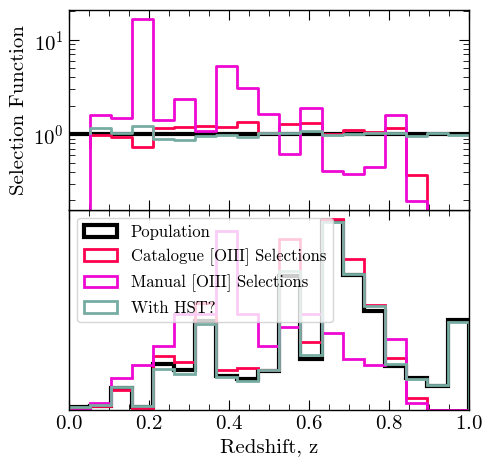

In [107]:
fig, ax = pf.create_plot(size=(4,2))

ax2 = fig.add_axes((0,1,1,1), sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.set_ylabel('Selection Function')
ax.set_xlabel('Redshift, z')

ax.set_xlim(0,1)
ax.set_yticks([])

binning = np.linspace(0,1,20)

ax.hist(maintab['Z'], bins=binning, density=True, histtype='step', lw=3, label='Population', edgecolor='k')
globhist, _ = np.histogram(maintab['Z'], bins=binning, density=True)

data = [(maintab[maintab['DETECTED?_OIII']==1])['Z'],tab['z'],ftab['Z']]
labz = ['Catalogue [OIII] Selections',r'Manual [OIII] Selections ','With HST?']
colorz = ['#ff004f',"#EF08D4",'#77aca2']

for i,d in enumerate(data):
    ax.hist(d, bins=binning, density=True, histtype='step', label = labz[i], edgecolor=colorz[i], lw=2 )

    hist, bedge = np.histogram(d, bins=binning, density=True)

    ax2.step(bedge[1:], hist/globhist, color=colorz[i], linewidth=2)

ax.legend(fontsize=12)

ax2.plot([-1,100],[1,1], color='black', lw=3, zorder=-1)
ax2.set_yscale('log')

pf.fix_plot([ax,ax2])